NumPy 실행 시간: 5.6258초


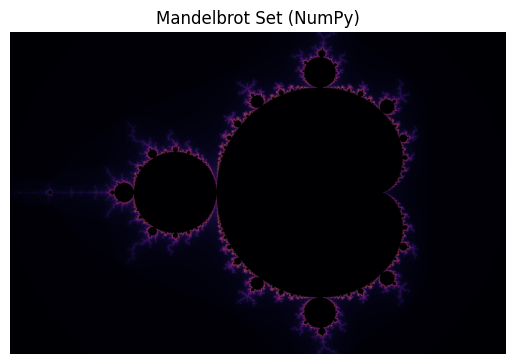

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time

# 해상도 (올리면 맥북 성능 바로 느낌 옴)
WIDTH = 3024
HEIGHT = 1964
MAX_ITER = 200

def mandelbrot_numpy():
    x = np.linspace(-2, 1, WIDTH)
    y = np.linspace(-1, 1, HEIGHT)
    X, Y = np.meshgrid(x, y)
    C = X + 1j * Y
    Z = np.zeros_like(C)
    div_time = np.zeros(C.shape, dtype=int)

    start = time.time()

    for i in range(MAX_ITER):
        Z = Z**2 + C
        diverged = np.abs(Z) > 2
        newly_diverged = diverged & (div_time == 0)
        div_time[newly_diverged] = i
        Z[diverged] = 2

    end = time.time()
    print(f"NumPy 실행 시간: {end - start:.4f}초")

    return div_time


def mandelbrot_python():
    start = time.time()
    result = np.zeros((HEIGHT, WIDTH))

    for i in range(HEIGHT):
        for j in range(WIDTH):
            x = -2 + (j / WIDTH) * 3
            y = -1 + (i / HEIGHT) * 2
            c = complex(x, y)
            z = 0
            for k in range(MAX_ITER):
                z = z*z + c
                if abs(z) > 2:
                    result[i, j] = k
                    break

    end = time.time()
    print(f"Pure Python 실행 시간: {end - start:.4f}초")

    return result


# 실행
data = mandelbrot_numpy()

plt.imshow(data, cmap='inferno')
plt.title("Mandelbrot Set (NumPy)")
plt.axis('off')
plt.show()